In [31]:
### libs

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
### dados

df = pd.read_table("https://drive.google.com/uc?export=view&id=11YsVJck74_gyADzGJSU9Uwn8cDq_l3BD",sep=";")

In [3]:
### EDA da massa

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
print("O conjunto de dados possui {} linhas e {} colunas".format(df.shape[0], df.shape[1]))

O conjunto de dados possui 4898 linhas e 12 colunas


<Axes: xlabel='quality', ylabel='count'>

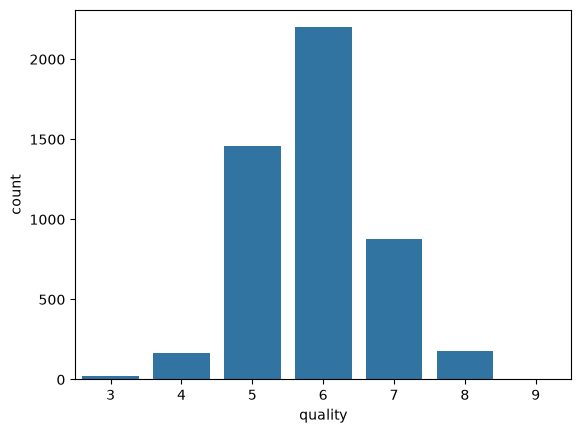

In [5]:
sns.countplot(x='quality', data=df)

In [6]:
print(df.groupby('quality').size())

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
dtype: int64


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [8]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
feature_names = df.columns.drop('quality')

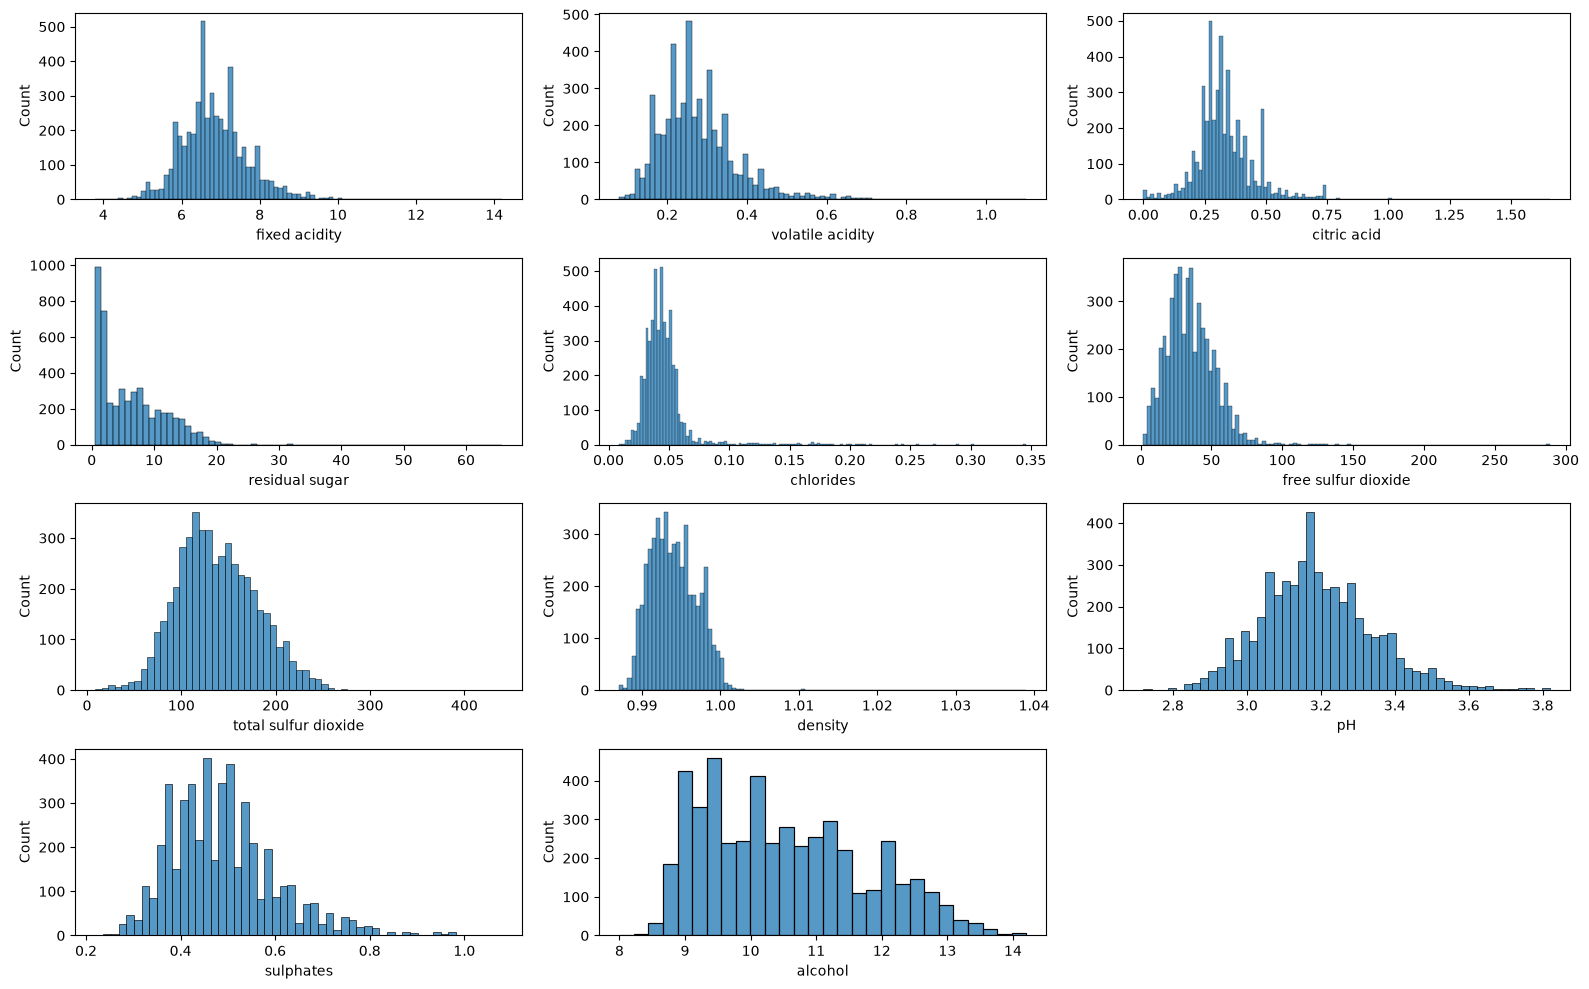

In [10]:
### Analisar a distribuição de dados de cada feature

plt.figure(figsize=(16, 10))
for indx, var  in enumerate(feature_names):
    plt.subplot(4, 3, indx+1)
    g = sns.histplot(x=var, data=df)
plt.tight_layout()

Pode-se ver que os dados possuem escalas diferentes e deste modo precisam ser normalizado


### Vendo correlações

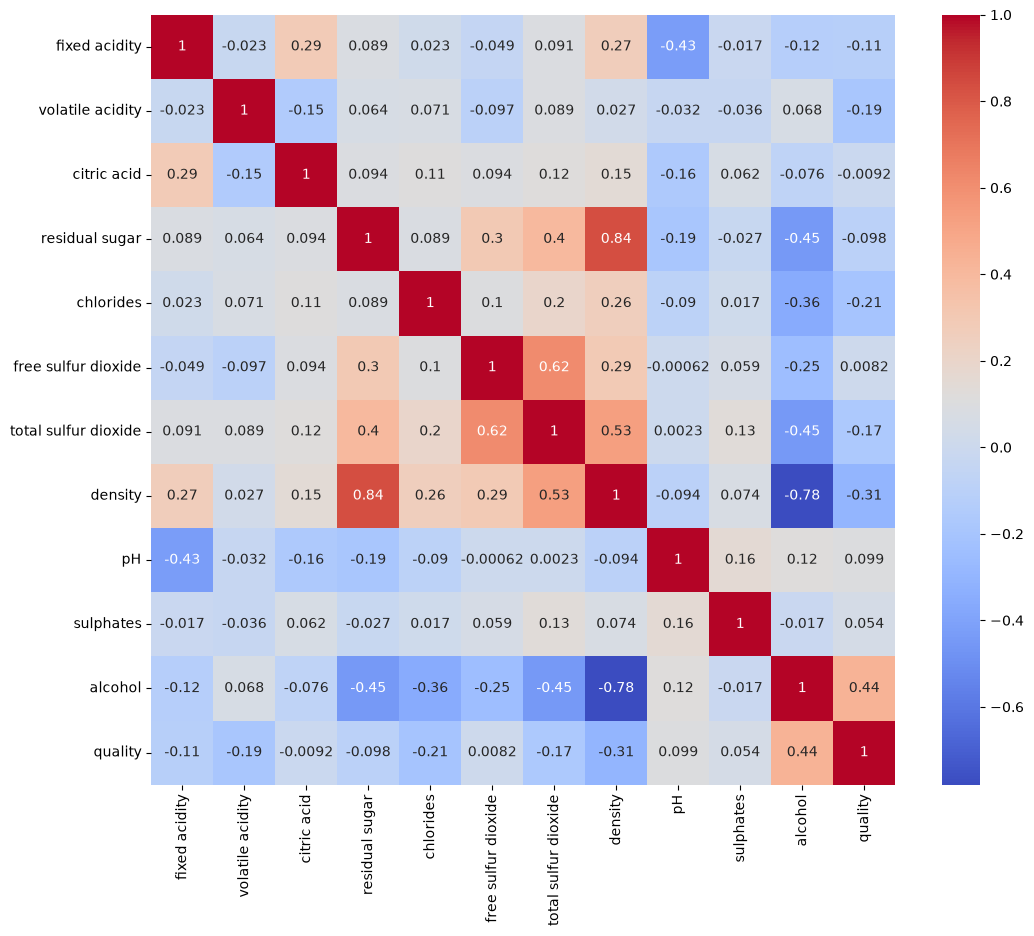

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap = 'coolwarm')
plt.show()

In [12]:
feature_names

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

<Axes: xlabel='quality', ylabel='fixed acidity'>

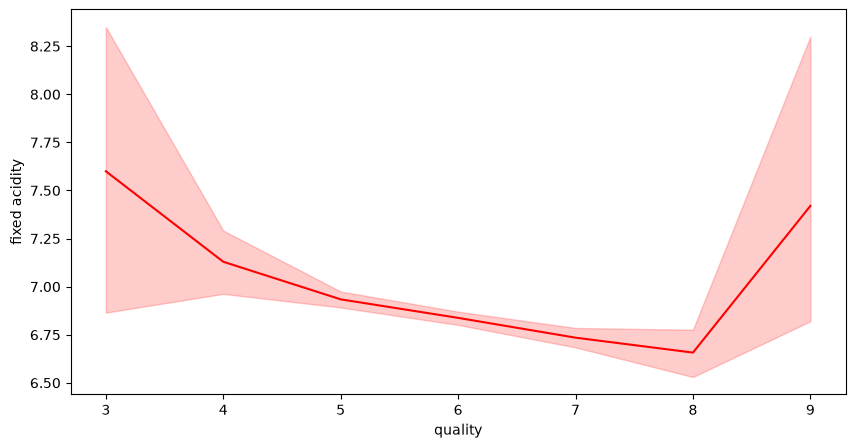

In [13]:
feature_sel = "fixed acidity" #@param {type:"string"}

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="quality",y=feature_sel,color='r')

### Pré-processamento

In [16]:
# convertendo em categorias binárias usando 7 como nota de corte

df['quality'] = df['quality'].replace([3,4,5,6,], 0)
df['quality'] = df['quality'].replace([7,8,9], 1)

<Axes: xlabel='quality', ylabel='count'>

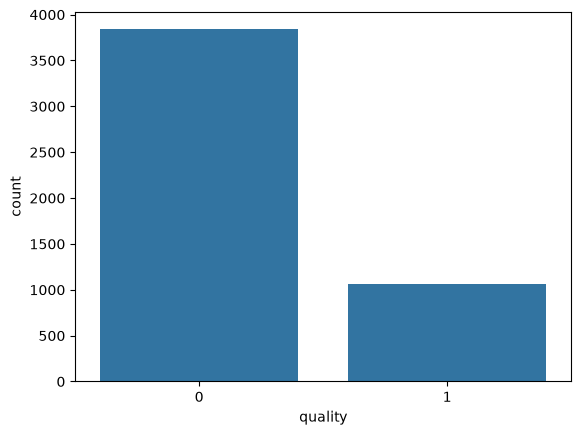

In [15]:
sns.countplot(x='quality', data=df)

In [21]:
X = df.drop(['quality'], axis=1)
y = df['quality'].values

In [30]:
train_ratio = 0.70
test_ratio = 0.15
validation_ratio = 0.15 / (train_ratio + test_ratio)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_ratio, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=validation_ratio, random_state=42)


print(X_train.shape)
print(X_test.shape)
print(X_val.shape)


(3428, 11)
(735, 11)
(735, 11)


In [33]:
### Normalizando após o split para não ter vazamentos de dados

scaler = MinxMaxScaler()

NameError: name 'MinxMaxScaler' is not defined